In [49]:
import numpy as np
import matplotlib.pyplot as plt

Samples shape: (4, 10)
f_ shape (100,)
[array(0.), array(0.00331089), array(0.0107761), array(0.01890276), array(0.02491165), array(0.02714303), array(0.02522516), array(0.01996942), array(0.01301859), array(0.00633362), array(0.00164451), array(0.), array(0.00152557), array(0.0054444), array(0.01034607), array(0.01462094), array(0.01693428), array(0.01660453), array(0.01377961), array(0.00936446), array(0.0047261), array(0.00126757), array(-2.22044605e-16), array(0.00124133), array(0.00453118), array(0.00878501), array(0.01263804), array(0.01487142), array(0.01478893), array(0.01242799), array(0.00854095), array(0.00435371), array(0.00117813), array(0.), array(0.00117122), array(0.00430247), array(0.00838904), array(0.01212981), array(0.01433844), array(0.01431719), array(0.01207572), array(0.00832626), array(0.0042569), array(0.00115503), array(0.), array(0.0011536), array(0.00424628), array(0.00829482), array(0.01201406), array(0.01422414), array(0.01422414), array(0.01201406), arra

C:\Users\kumar\AppData\Local\Temp\ipykernel_28992\159168344.py:85: RuntimeWarning: invalid value encountered in sqrt
  uper_bound = f_ + np.sqrt(vars)


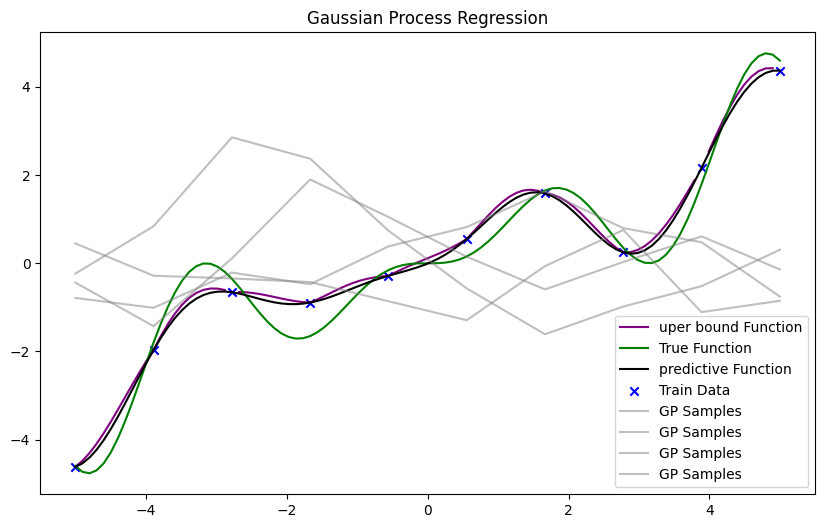

In [55]:
def rbf(x1, x2, amplitude=1.0, length_scale=1.0):
    """
    Radial Basis Function (Gaussian Kernel)
    Args:
        x1: array-like, shape (n1,)
        x2: array-like, shape (n2,)
    Returns:
        Kernel matrix of shape (n1, n2)
    """
    x1 = x1.flatten()
    x2 = x2.flatten()
    square_dist = (x1[:, np.newaxis] - x2[np.newaxis, :]) ** 2  # pair-wise squared distances
    return amplitude * np.exp(-square_dist / (2 * length_scale ** 2))

def sample_gp(K,number_sample=4):
    """
    Generate samples from a Gaussian Process
    Args:
        K: Covariance matrix
        num_samples: Number of samples to generate
    Returns:
        Samples from the GP
    """
    mean = np.zeros(K.shape[0])
    samples = np.random.multivariate_normal(mean,K,number_sample)
    print(f"Samples shape: {samples.shape}")
    return samples
def generate_noise_data(true_function,n_data=10,noise_std=0.5):
    """
    Generate noisy data from the true function
    Args:
        true_function: Function to generate the data
        n_data: Number of data points
        noise_std: Standard deviation of Gaussian noise
    Returns:
        x: Input data
        y: Noisy observations
        true_y: True function values
    """
    x = np.linspace(-5, 5, n_data)
    true_y = true_function(x)
    y = true_y + np.random.normal(0, noise_std, n_data)
    return x.reshape(-1, 1), y.reshape(-1, 1), true_y

# Define the true function
true_function = lambda x: x*np.sin(x)**2
x_conti = np.linspace(-5,5,100)
# Generate Data
X, y, true_y = generate_noise_data(true_function, n_data=10, noise_std=0.3)

X_train,y_train = X,y
# Compute the covariance
K = rbf(X_train,X_train,length_scale= 1) # (n,n)
Ky = K #+ 1e-1*np.eye(K.shape[0])

# Sample from Gaussian 
samples = sample_gp(Ky)


f = true_function(x_conti)
f_ = []
vars = []
for i,bin in enumerate(x_conti):
    x_test = np.array(bin).reshape(-1,1)

    k_ = rbf(X_train,x_test)

    k__ = rbf(x_test,x_test)

    # Solve for mean and Variance 
    m = np.linalg.solve(K,y_train)

    mu_ = k_.T.dot(m) # Posterior mean
    mu_ = np.squeeze(mu_)
    f_.append(mu_)

    # Solve for posterior variance 
    alpha = np.linalg.solve(K,k_)
    sigma_ = k__ - k_.T.dot(alpha)
    vars.append(sigma_.squeeze())
    
f_ = np.array(f_)
print(f"f_ shape {f_.shape}")
print(vars)
uper_bound = f_ + np.sqrt(vars)
# Plot the result
plt.figure(figsize=(10, 6))
plt.plot(x_conti, uper_bound, label="uper bound Function", color="purple")
plt.plot(x_conti, f, label="True Function", color="green")
plt.plot(x_conti, f_, label="predictive Function", color="black")
plt.scatter(X_train, y_train, label="Train Data", color="blue", marker="x")
plt.plot(X_train, samples.T, alpha=0.5, label="GP Samples", color="gray")
# plt.errorbar(x_test.flatten(), mu_, yerr=np.sqrt(sigma_), fmt='o', color='orange', label="GP Prediction")
plt.title("Gaussian Process Regression")
plt.legend()
plt.show()







In [51]:
def rbf(x1, x2, amplitude=1.0, length_scale=1.0):
    """
    Radial Basis Function (Gaussian Kernel)
    Args:
        x1: array-like, shape (n1,d)
        x2: array-like, shape (n2,d)
        where d is the dim of input 
    Returns:
        Kernel matrix of shape (n1, n2)
    """
    square_dist = np.sum((x1[:,np.newaxis,] - x2[np.newaxis,:,])**2,axis=2) # x1-->(n1,1,d) - x2-->(1,n2,d) ----->(n1,n2,d).sumover d
    return amplitude*np.exp(-square_dist/(2*length_scale**2))

def sample_gp(K,number_sample = 4):
    """
    Generate samples from a Gaussian Process
    Args:
        K: Covariance matrix
        num_samples: Number of samples to generate
    Returns:
        Samples from the GP
        samples: shape (number_samples,n)
    """
    mean = np.zeros(K.shape[0])
    samples = np.random.multivariate_normal(mean,K,number_sample)
    return samples 
def generate_noise_data(true_function,n_data= 10,noise_std = 0.5,input_dim = 1):
    x = np.random.uniform(-5,-5,(n_data,input_dim))
    true_y = true_function(x)
    y = true_y + np.random.normal(0,noise_std,n_data)
    return x,y.reshape(-1,1), true_y

#Define the true function 
true_function = lambda x: np.sin(np.linalg.norm(x, axis=1)) * np.exp(-np.linalg.norm(x, axis=1)**2)

# Generate Data 
X,Y,true_Y = generate_noise_data(true_function,n_data=20,noise_std=0.3,input_dim=2)
X_train, X_test = X[::2], X[1::2]
y_train, Y_test = Y[::2], Y[1::2]

K = rbf(X_train,X_train)  # shape (n,n)
print(f"K shape {K.shape}")
Ky = K + 1e-6*np.eye(K.shape[0])
# Predict for a test point
x_test = X_test[5:6]  # Single test point
k_ = rbf(X_train, x_test)
k__ = rbf(x_test, x_test)

# Solve for posterior mean and variance
m = np.linalg.solve(K, y_train)
mu_ = k_.T.dot(m)  # Posterior mean

alpha = np.linalg.solve(K, k_)
sigma_ = k__ - k_.T.dot(alpha)  # Posterior variance

# Plot the results (for the first two dimensions)
plt.figure(figsize=(10, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], label="Train Data", color="blue", marker="x")
plt.scatter(X_test[:, 0], X_test[:, 1], label="Test Data", color="red", marker="o")
plt.scatter(x_test[:, 0], x_test[:, 1], label="Test Point", color="orange", marker="o")
plt.title("Gaussian Process Regression (2D Inputs)")
plt.legend()
plt.show()

    
    
    

    

K shape (10, 10)


LinAlgError: Singular matrix